In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [49]:
df = pd.read_csv("billionaire_cleaned.csv")
df.tail()

,year,rank,net_worth,full_name,age,gender,country_of_citizenship,city_of_residence,business_category,business_industries,organization_name,position_in_organization,self_made,wealth_status
34506,2024,2692,1.0,Zhang Hong,63,Female,China,Hangzhou,Energy,['Energy'],Unspecified Organization,Unspecified Position,True,Decreased
34507,2024,2692,1.0,Zheng Xiaodong,60,Male,China,Shanghai,Manufacturing,['Manufacturing'],Unspecified Organization,Unspecified Position,True,Decreased
34508,2024,2692,1.0,Zhong Sheng Jian,66,Male,Singapore,Singapore,Real Estate,['Real Estate'],Unspecified Organization,Unspecified Position,True,Decreased
34509,2024,2692,1.0,Zhou Junjie,55,Male,China,Hangzhou,Manufacturing,['Manufacturing'],Unspecified Organization,Unspecified Position,True,Unknown
34510,2024,2692,1.0,Zhu Yiwen & family,60,Male,China,Shanghai,Healthcare,['Healthcare'],Unspecified Organization,Unspecified Position,True,Decreased


In [65]:
df_unique_position = df.sort_values("year").drop_duplicates(subset="full_name", keep="last")[["full_name", "position_in_organization"]]
position_counts = df_unique_position["position_in_organization"].value_counts().reset_index()
position_counts.columns = ["position_in_organization", "count"]
position_counts = position_counts.drop(index=0).reset_index(drop=True)
position_counts.head(20)

,position_in_organization,count
0,Investor,55
1,Founder,46
2,Entrepreneur,45
3,Chairman,43
4,Chairman and CEO,40
5,Cofounder,35
6,CEO,33
7,President,9
8,Founder and CEO,9
9,Owner,9


In [79]:
df_unique_org = df.sort_values("year").drop_duplicates(subset="full_name", keep="last")[["full_name", "organization_name"]]
org_counts = df_unique_org["organization_name"].value_counts().reset_index()
org_counts.columns = ["organization_name", "count"]
org_counts.head(20)

,organization_name,count
0,Unspecified Organization,4788
1,Shinsegae,4
2,Meta Platforms,4
3,Hyundai Motor,3
4,Lotte Shopping,3
5,Franklin Resources,3
6,Rocket Internet,3
7,Gap Inc.,3
8,LG Electronics,2
9,News Corp,2


In [50]:
df_unique = df.sort_values("year").drop_duplicates(subset="full_name", keep="last")[["full_name", "country_of_citizenship"]]
df_unique.tail()

,full_name,country_of_citizenship
34506,Zhang Hong,China
34507,Zheng Xiaodong,China
34508,Zhong Sheng Jian,Singapore
34509,Zhou Junjie,China
34510,Zhu Yiwen & family,China


In [51]:
country_counts = df_unique["country_of_citizenship"].value_counts().reset_index()
country_counts.columns = ["country_of_citizenship", "count"]
country_counts

,country_of_citizenship,count
0,United States,1265
1,China,1162
2,India,304
3,Germany,258
4,Russia,216
...,...,...
83,Liechtenstein,1
84,Barbados,1
85,Luxembourg,1
86,Bangladesh,1


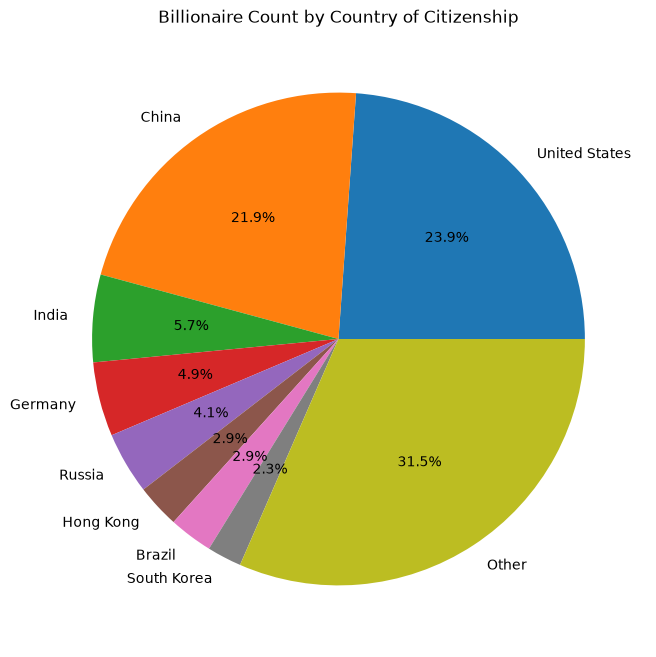

In [52]:
top_n = 8
top_countries = country_counts.nlargest(top_n, "count").copy()
other_total = country_counts.iloc[top_n:]["count"].sum()

top_countries = pd.concat([
    top_countries,
    pd.DataFrame({"country_of_citizenship": ["Other"], "count": [other_total]})
], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(top_countries["count"], labels=top_countries["country_of_citizenship"], autopct="%1.1f%%")
plt.title("Billionaire Count by Country of Citizenship")
plt.show()

In [53]:
df_unique_gender = df.sort_values("year").drop_duplicates(subset="full_name", keep="last")[["full_name", "gender"]]
gender_counts = df_unique_gender["gender"].value_counts().reset_index()
gender_counts.columns = ["gender", "count"]
gender_counts

,gender,count
0,Male,4507
1,Female,625
2,Group/Family,169


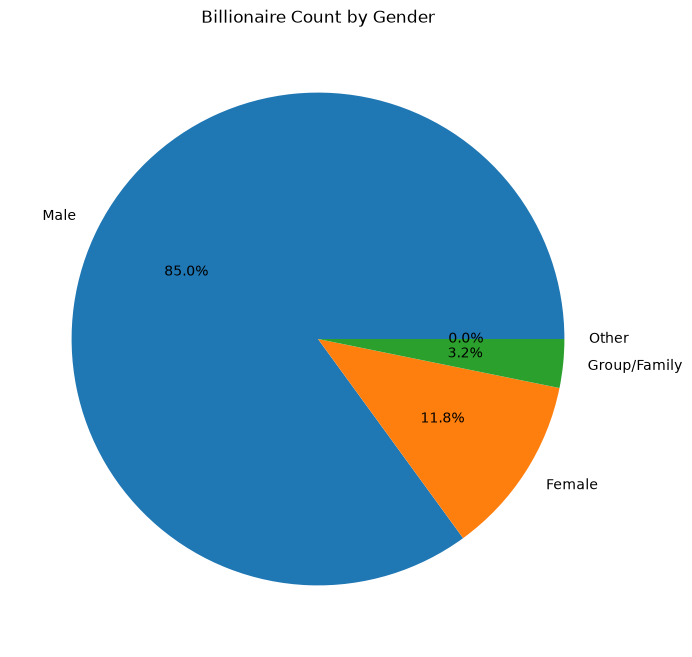

In [54]:
top_n = 3
top_countries = gender_counts.nlargest(top_n, "count").copy()
other_total = gender_counts.iloc[top_n:]["count"].sum()

top_countries = pd.concat([
    top_countries,
    pd.DataFrame({"gender": ["Other"], "count": [other_total]})
], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(top_countries["count"], labels=top_countries["gender"], autopct="%1.1f%%")
plt.title("Billionaire Count by Gender")
plt.show()

In [55]:
df_unique_category = df.sort_values("year").drop_duplicates(subset="full_name", keep="last")[["full_name", "business_category"]]
category_counts = df_unique_category["business_category"].value_counts().reset_index()
category_counts.columns = ["business_category", "count"]
category_counts

,business_category,count
0,Manufacturing,621
1,Technology,562
2,Finance & Investments,529
3,Fashion & Retail,475
4,Real Estate,375
5,Diversified,367
6,Healthcare,349
7,Unspecified Category,323
8,Food & Beverage,304
9,Energy,182


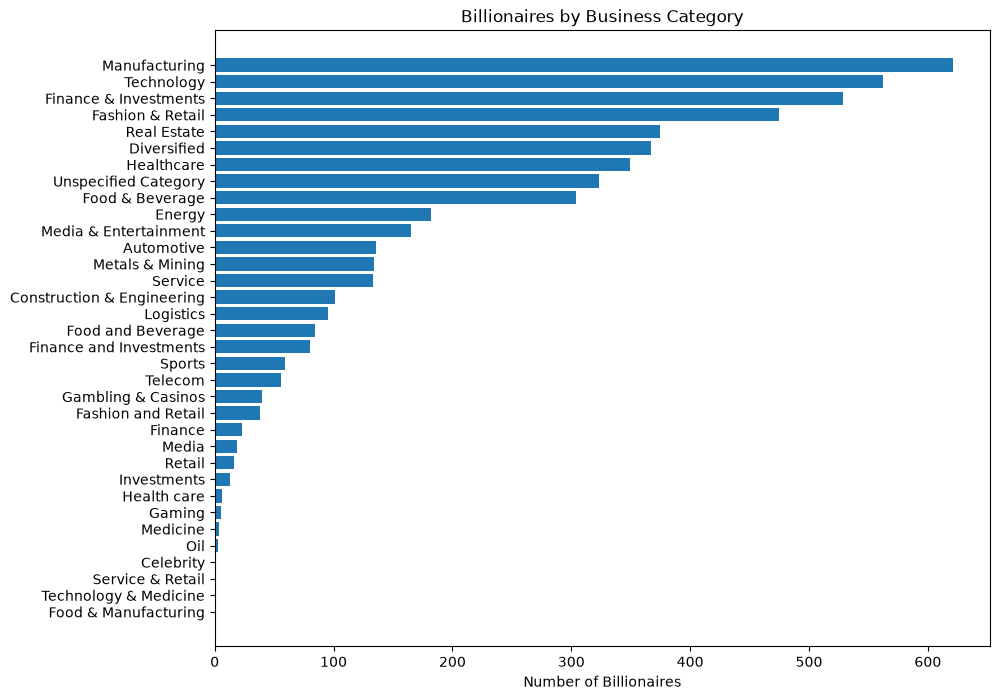

In [56]:
plt.figure(figsize=(10, 8))
plt.barh(category_counts["business_category"], category_counts["count"])
plt.gca().invert_yaxis() 
plt.xlabel("Number of Billionaires")
plt.title("Billionaires by Business Category")
plt.show()

In [57]:
df_unique_self_made = df.sort_values("year").drop_duplicates(subset="full_name", keep="last")[["full_name", "self_made"]]
df_unique_self_made.tail()

,full_name,self_made
34506,Zhang Hong,True
34507,Zheng Xiaodong,True
34508,Zhong Sheng Jian,True
34509,Zhou Junjie,True
34510,Zhu Yiwen & family,True


In [58]:
self_made_counts = df_unique_self_made["self_made"].value_counts().reset_index()
self_made_counts.columns = ["self_made", "count"]
self_made_counts

,self_made,count
0,True,3547
1,False,1617


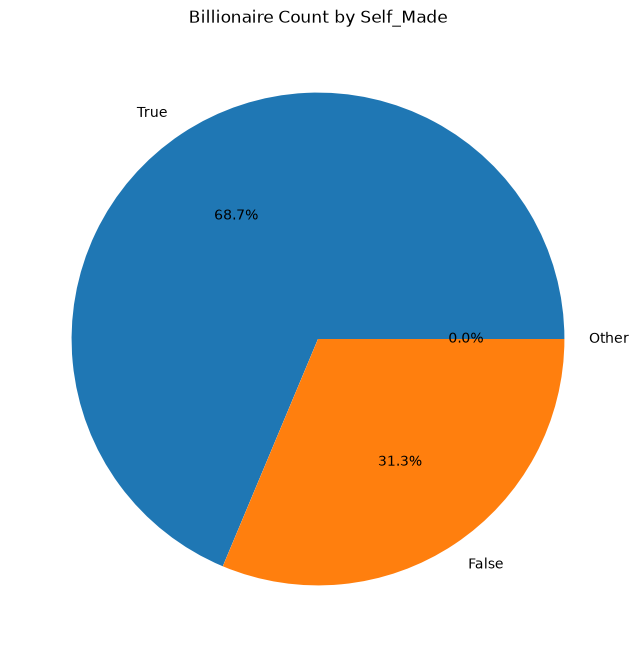

In [59]:
top_n = 2
top_countries = self_made_counts.nlargest(top_n, "count").copy()
other_total = self_made_counts.iloc[top_n:]["count"].sum()

top_countries = pd.concat([
    top_countries,
    pd.DataFrame({"self_made": ["Other"], "count": [other_total]})
], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(top_countries["count"], labels=top_countries["self_made"], autopct="%1.1f%%")
plt.title("Billionaire Count by Self_Made")
plt.show()

In [60]:
df_unique = df.sort_values("year").drop_duplicates(subset="full_name", keep="last")[
    ["full_name", "business_category", "country_of_citizenship"]
]

category_country_counts = df_unique.groupby(["business_category", "country_of_citizenship"]).size().reset_index(name="count")
category_country_counts = category_country_counts.sort_values(["business_category", "count"], ascending=[True, False])
category_country_counts

,business_category,country_of_citizenship,count
4,Automotive,China,32
21,Automotive,United States,26
6,Automotive,Germany,19
8,Automotive,India,18
5,Automotive,France,4
...,...,...,...
691,Unspecified Category,Romania,1
696,Unspecified Category,Spain,1
697,Unspecified Category,Sweden,1
702,Unspecified Category,Ukraine,1


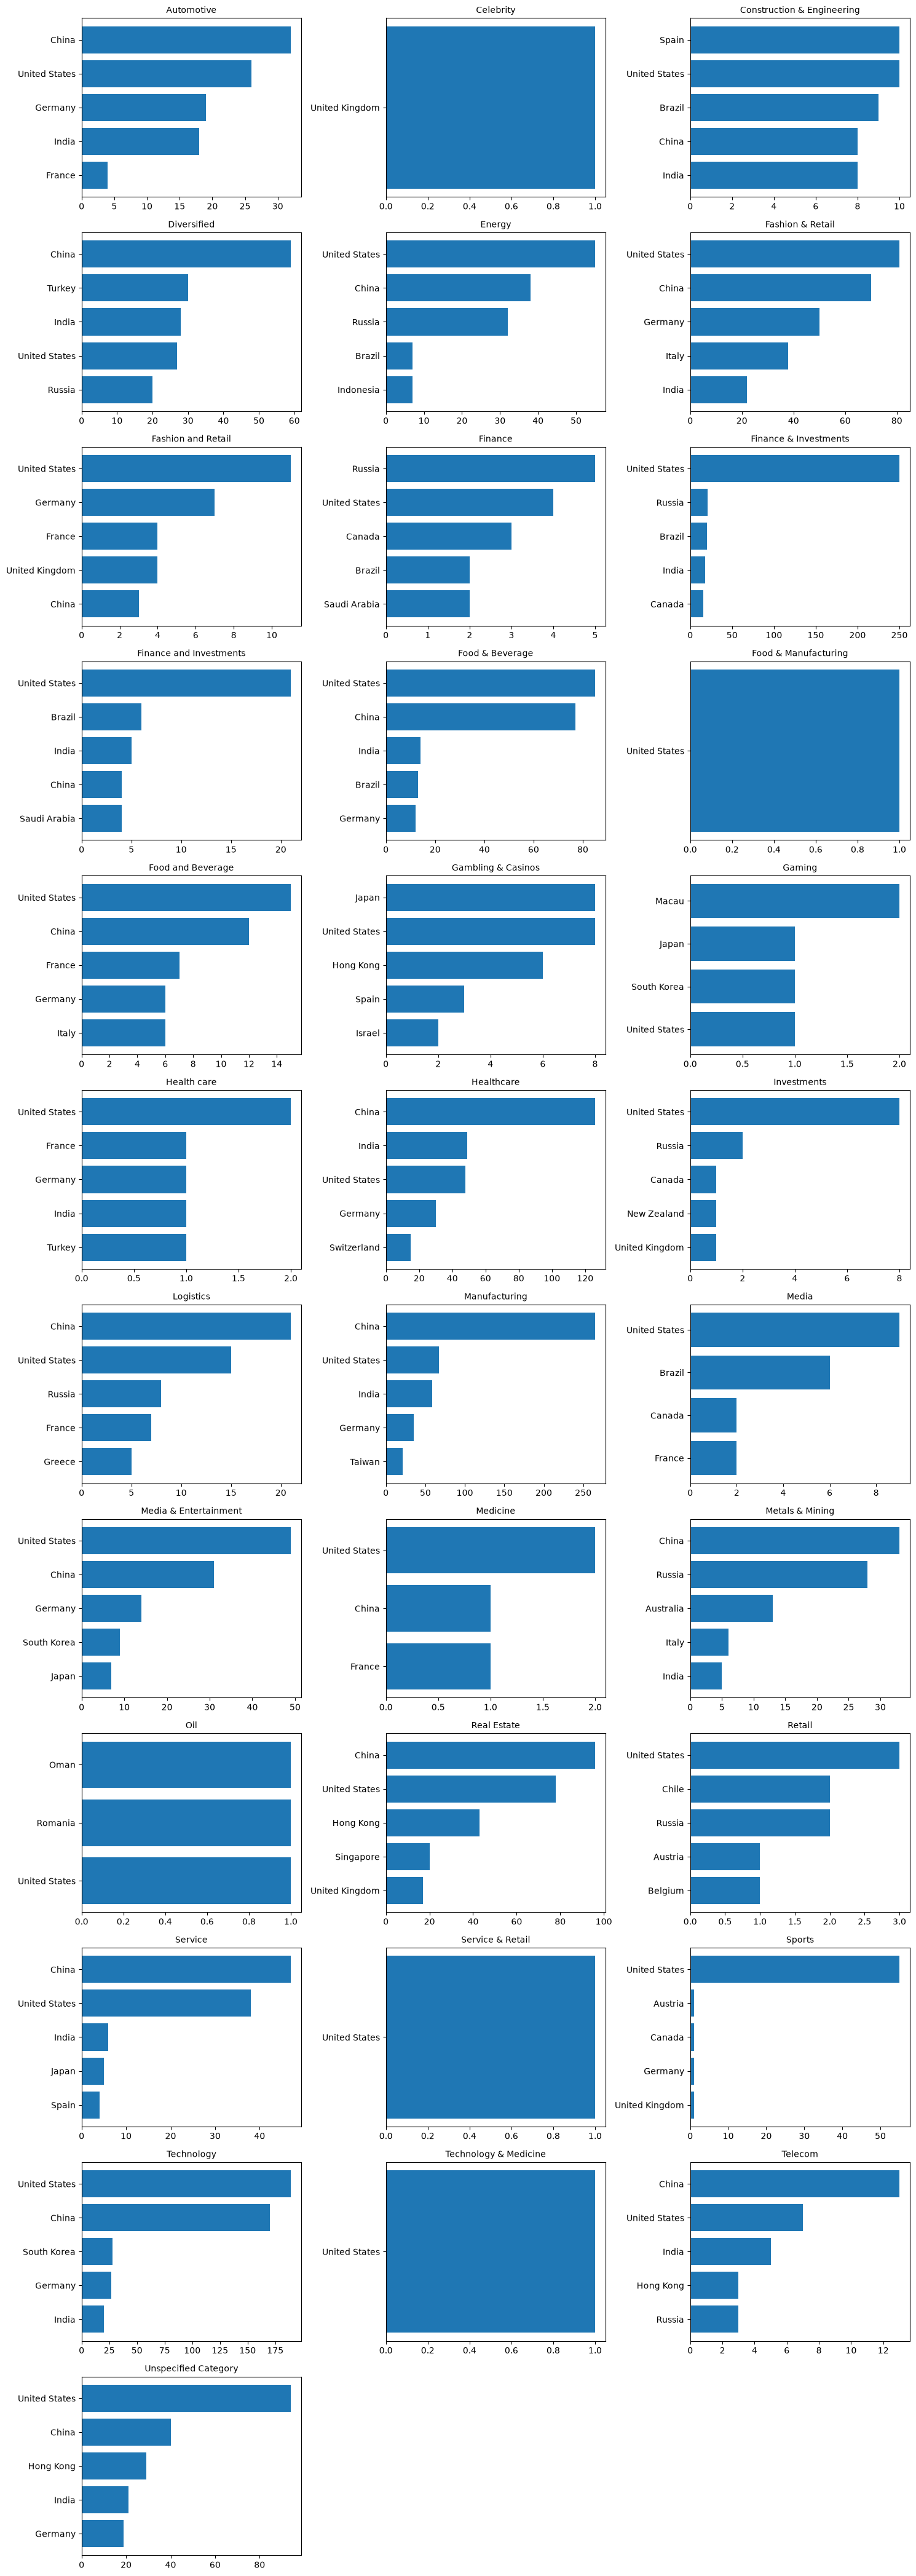

In [62]:
categories = category_country_counts["business_category"].unique()
n_cats = len(categories)

n_cols = 3
n_rows = math.ceil(n_cats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, cat in enumerate(categories):
    subset = category_country_counts[category_country_counts["business_category"] == cat].nlargest(5, "count")
    axes[i].barh(subset["country_of_citizenship"], subset["count"])
    axes[i].invert_yaxis()
    axes[i].set_title(cat, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [66]:
age_by_year = df.groupby("year")["age"].mean().reset_index()
age_by_year

,year,age
0,1997,71.000000
1,1998,65.000000
2,1999,62.375000
3,2000,53.500000
4,2001,57.767164
5,2002,59.132132
6,2003,59.237952
7,2004,59.525463
8,2005,60.318868
9,2006,59.863057


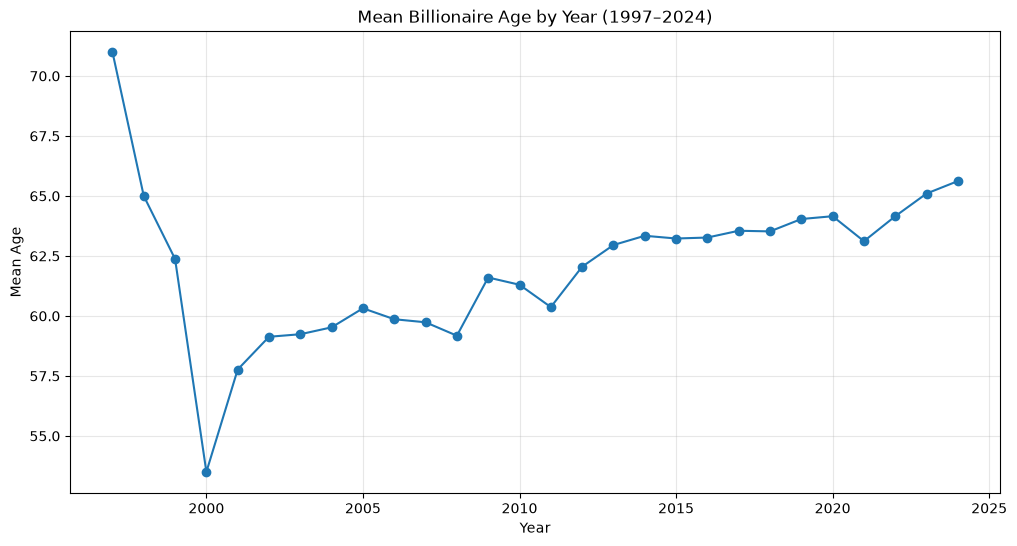

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(age_by_year["year"], age_by_year["age"], marker="o")
plt.xlabel("Year")
plt.ylabel("Mean Age")
plt.title("Mean Billionaire Age by Year (1997–2024)")
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
billions_per_country_year = df.groupby(["year", "country_of_citizenship"])["net_worth"].sum().reset_index()
billions_per_country_year

,year,country_of_citizenship,net_worth
0,1997,Thailand,3.8
1,1998,Lebanon,3.3
2,1999,Brazil,1.0
3,1999,Colombia,1.3
4,1999,France,1.8
...,...,...,...
1460,2024,United States,5700.8
1461,2024,Uruguay,2.2
1462,2024,Venezuela,4.4
1463,2024,Vietnam,13.9


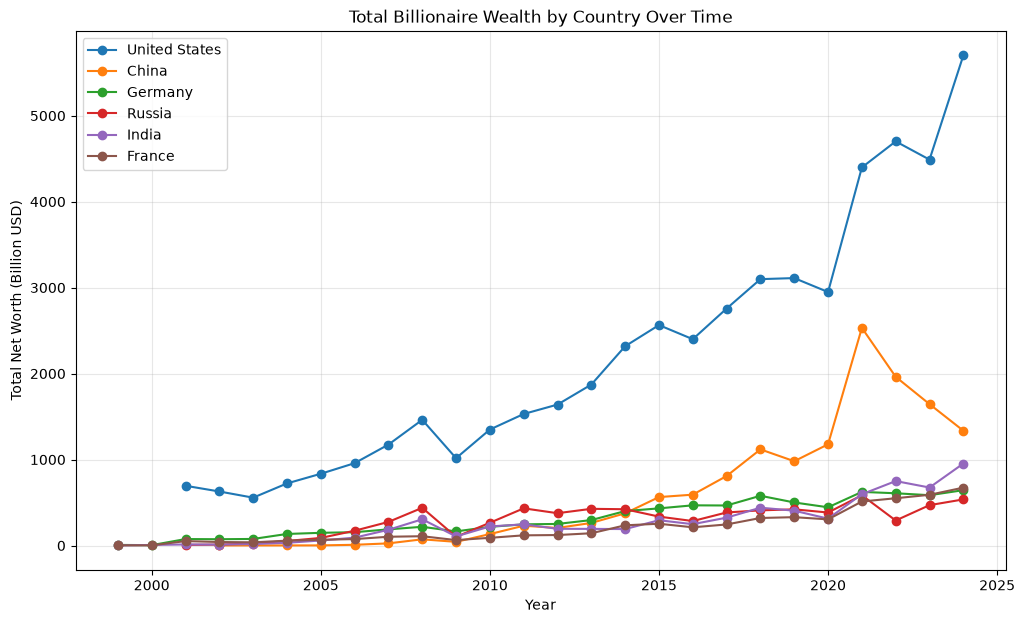

In [73]:
top_countries = billions_per_country.head(6)["country_of_citizenship"].tolist()

plt.figure(figsize=(12, 7))
for country in top_countries:
    subset = billions_per_country_year[billions_per_country_year["country_of_citizenship"] == country]
    plt.plot(subset["year"], subset["net_worth"], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Total Net Worth (Billion USD)")
plt.title("Total Billionaire Wealth by Country Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [74]:
count_per_country_year = df.groupby(["year", "country_of_citizenship"]).size().reset_index(name="billionaire_count")
count_per_country_year

,year,country_of_citizenship,billionaire_count
0,1997,Thailand,2
1,1998,Lebanon,1
2,1999,Brazil,1
3,1999,Colombia,1
4,1999,France,1
...,...,...,...
1460,2024,United States,813
1461,2024,Uruguay,2
1462,2024,Venezuela,1
1463,2024,Vietnam,6


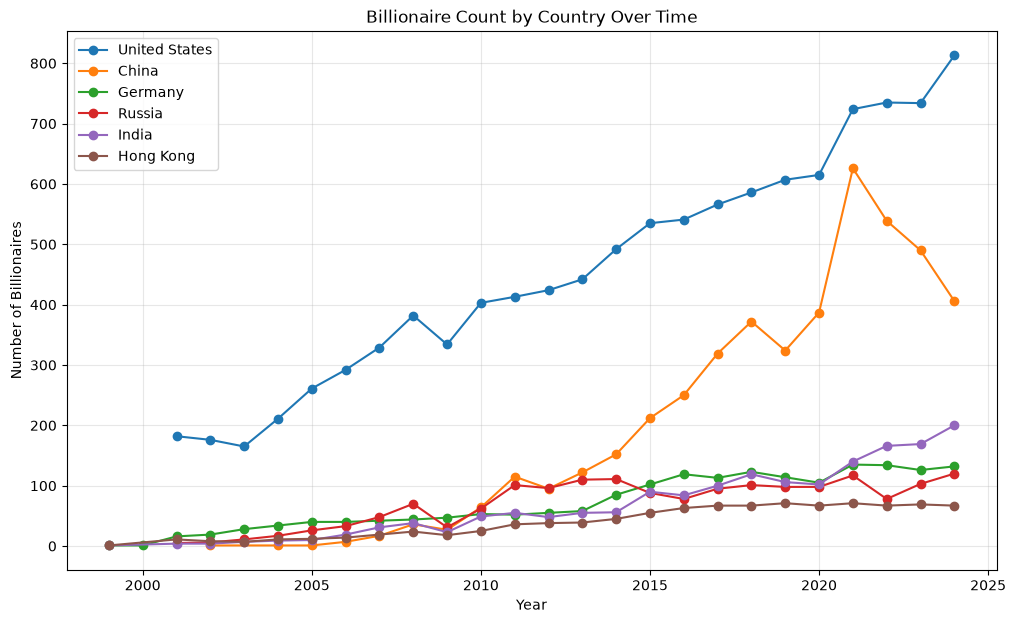

In [75]:
top_countries = df["country_of_citizenship"].value_counts().head(6).index.tolist()

plt.figure(figsize=(12, 7))
for country in top_countries:
    subset = count_per_country_year[count_per_country_year["country_of_citizenship"] == country]
    plt.plot(subset["year"], subset["billionaire_count"], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Number of Billionaires")
plt.title("Billionaire Count by Country Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [80]:
category_by_year = df.groupby(["year", "business_category"]).size().reset_index(name="count")
category_by_year

,year,business_category,count
0,1997,Finance and Investments,1
1,1997,Unspecified Category,1
2,1998,Unspecified Category,1
3,1999,Fashion & Retail,1
4,1999,Finance and Investments,1
...,...,...,...
495,2024,Real Estate,190
496,2024,Service,52
497,2024,Sports,49
498,2024,Technology,342


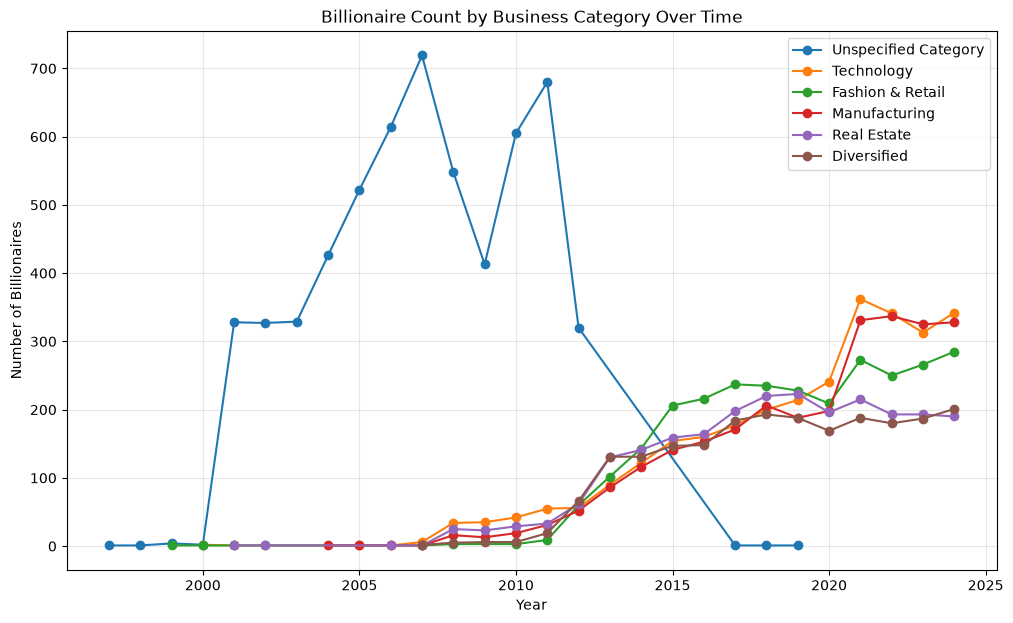

In [81]:
top_categories = df["business_category"].value_counts().head(6).index.tolist()

plt.figure(figsize=(12, 7))
for category in top_categories:
    subset = category_by_year[category_by_year["business_category"] == category]
    plt.plot(subset["year"], subset["count"], marker="o", label=category)

plt.xlabel("Year")
plt.ylabel("Number of Billionaires")
plt.title("Billionaire Count by Business Category Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [82]:
category_country_year = df.groupby(["year", "country_of_citizenship", "business_category"]).size().reset_index(name="count")
category_country_year

,year,country_of_citizenship,business_category,count
0,1997,Thailand,Finance and Investments,1
1,1997,Thailand,Unspecified Category,1
2,1998,Lebanon,Unspecified Category,1
3,1999,Brazil,Food and Beverage,1
4,1999,Colombia,Food and Beverage,1
...,...,...,...,...
6363,2024,Vietnam,Diversified,2
6364,2024,Vietnam,Finance & Investments,1
6365,2024,Vietnam,Food & Beverage,1
6366,2024,Vietnam,Manufacturing,1


In [86]:
def plot_country_category_trend(country, top_n=6):
    subset = category_country_year[category_country_year["country_of_citizenship"] == country]
    top_categories = subset.groupby("business_category")["count"].sum().nlargest(top_n).index.tolist()

    plt.figure(figsize=(12, 7))
    for category in top_categories:
        cat_subset = subset[subset["business_category"] == category]
        plt.plot(cat_subset["year"], cat_subset["count"], marker="o", label=category)

    plt.xlabel("Year")
    plt.ylabel("Number of Billionaires")
    plt.title(f"Business Category Trends Over Time — {country}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


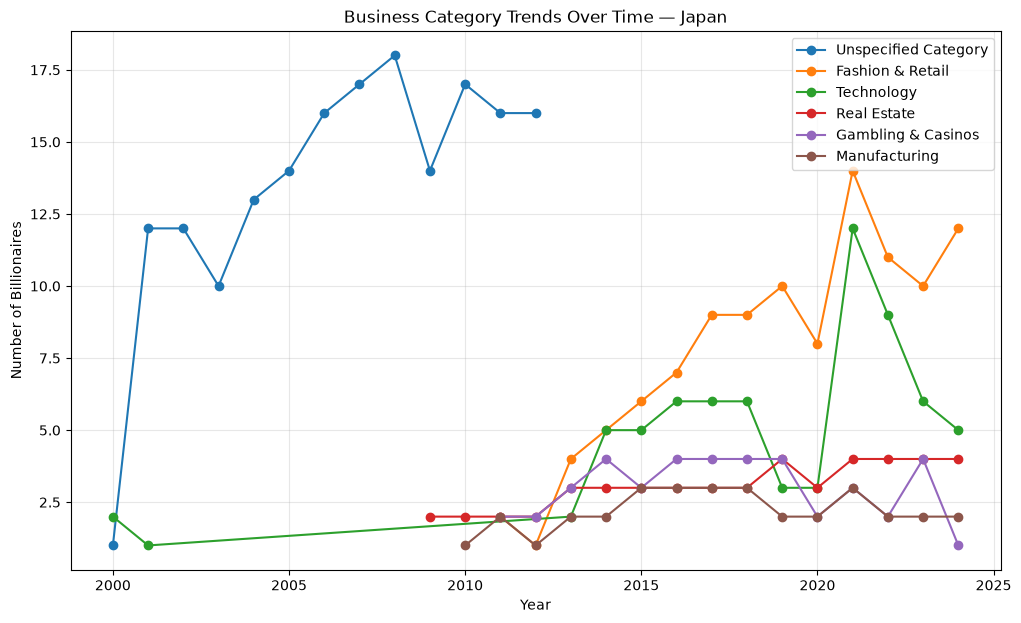

In [89]:

plot_country_category_trend("Japan")

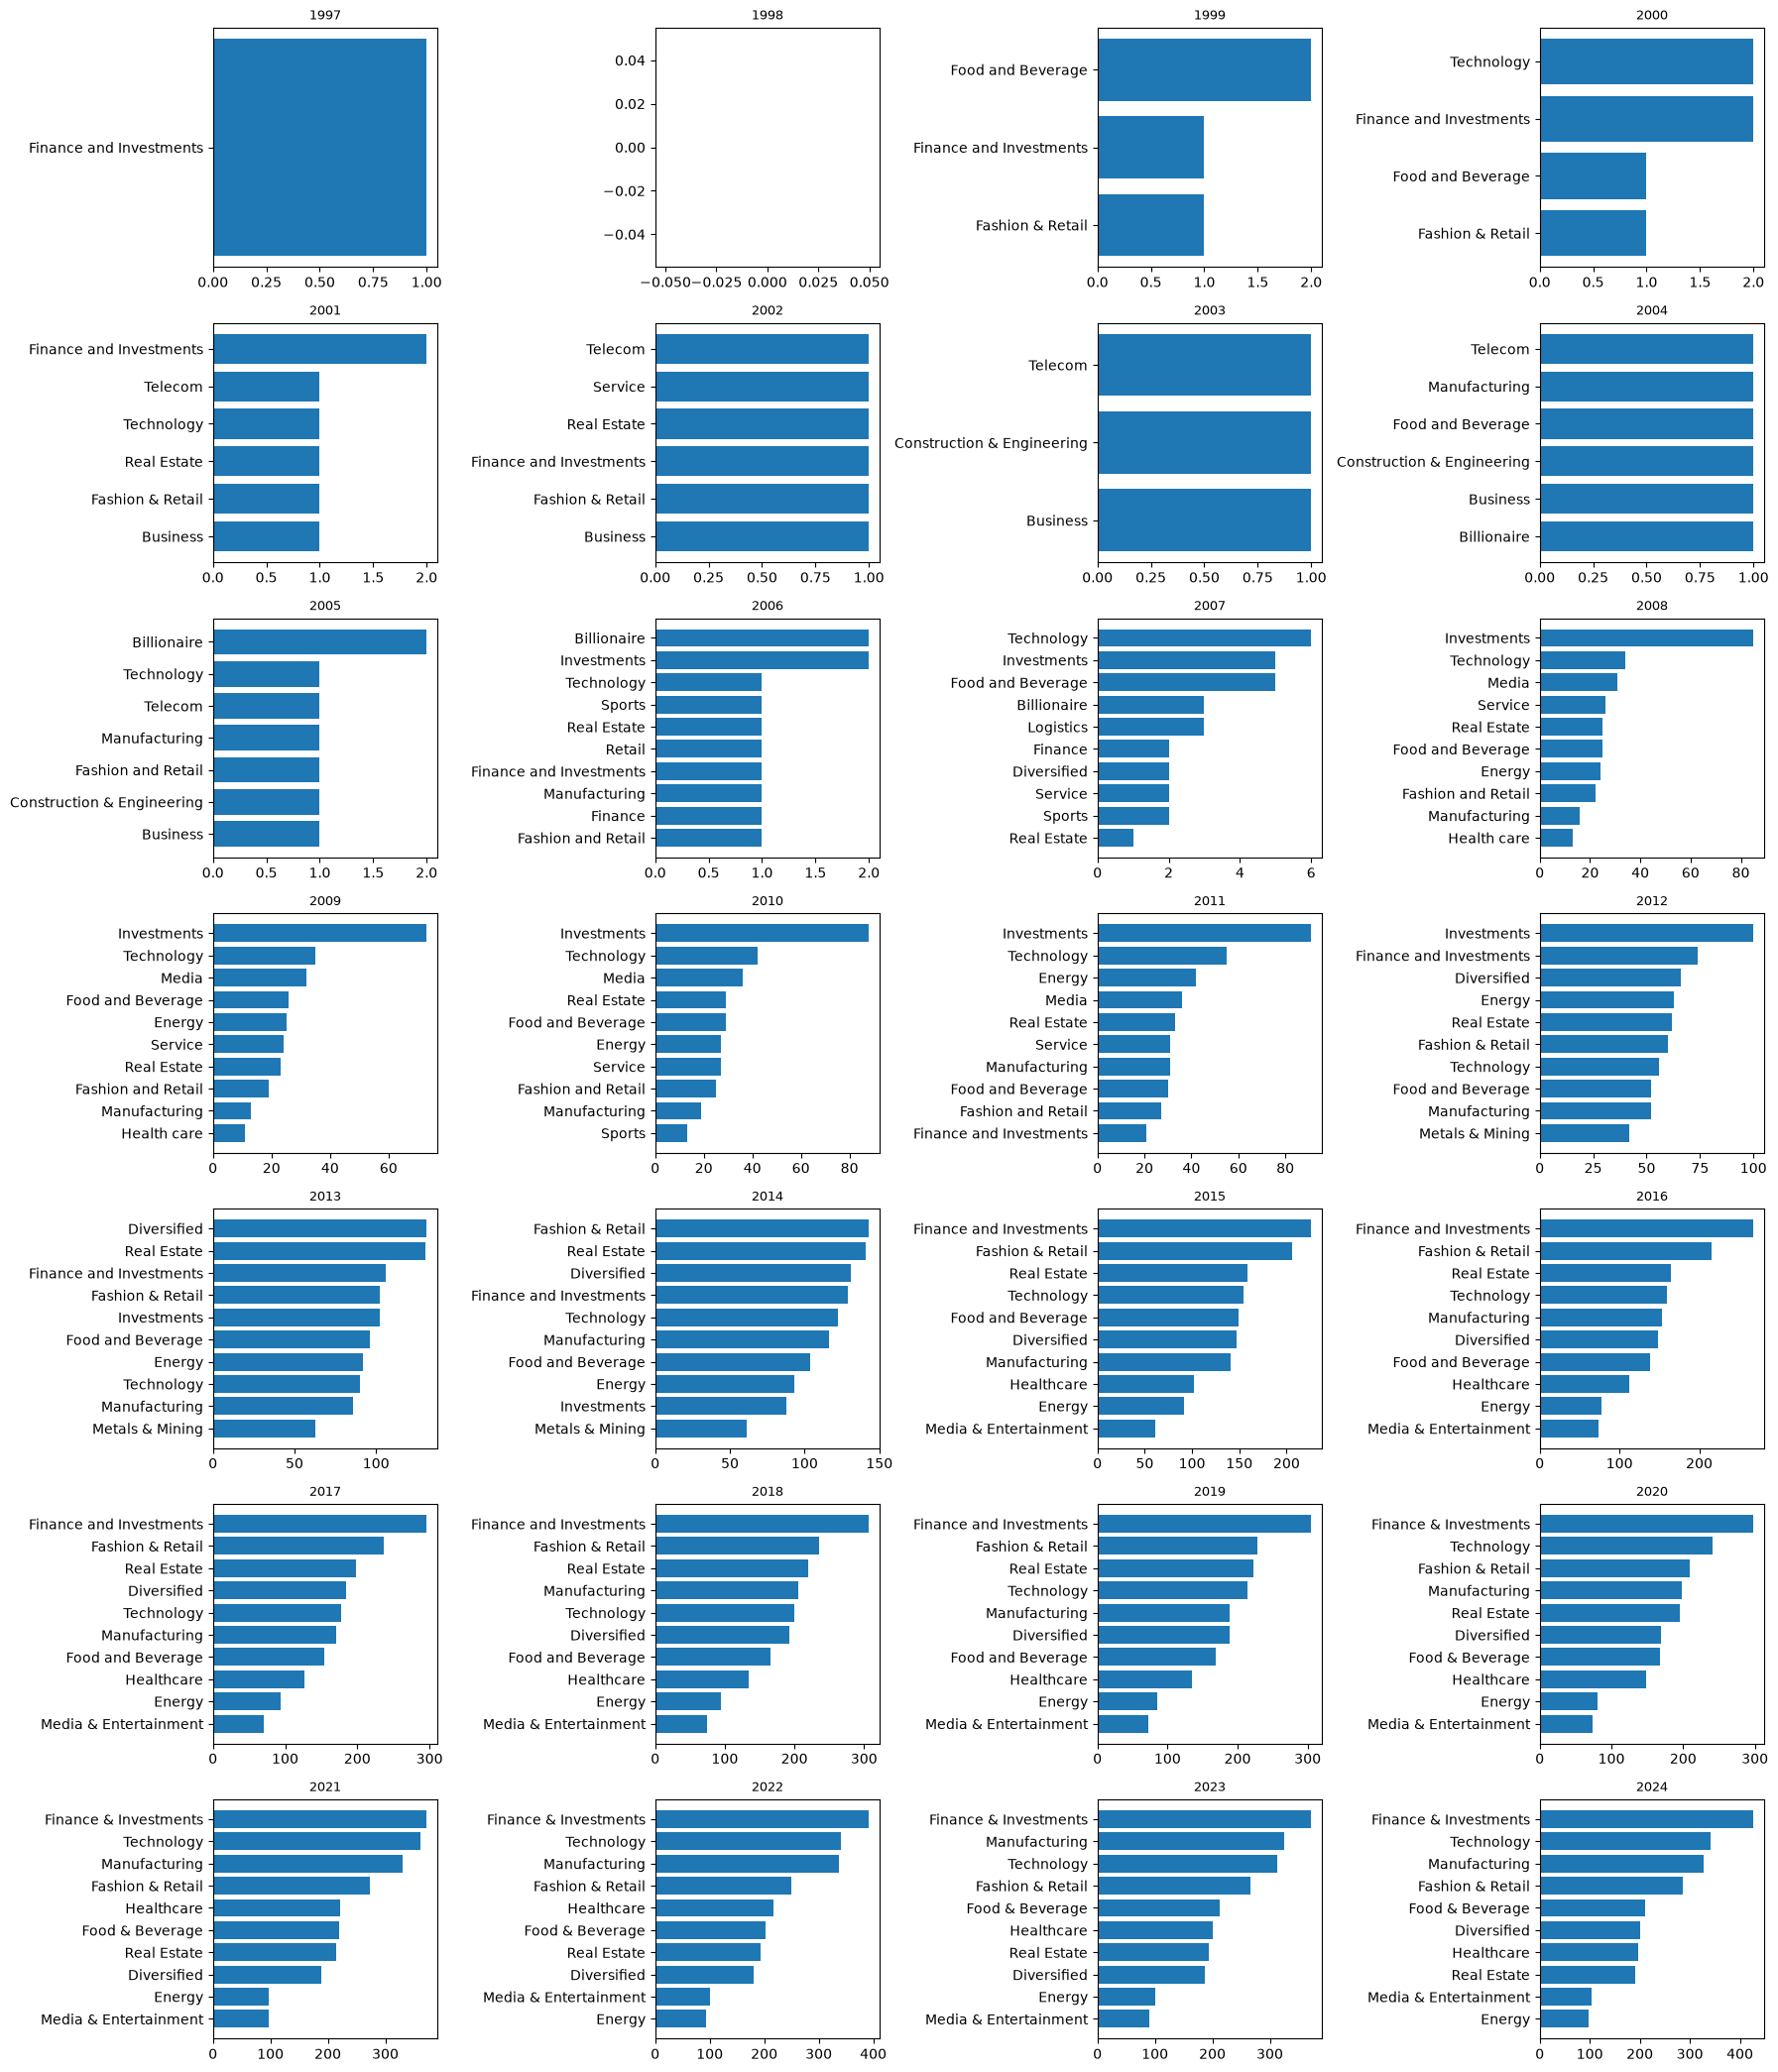

In [94]:
category_by_year_filtered = category_by_year[category_by_year["business_category"] != "Unspecified Category"]

years = sorted(df["year"].unique())
n_cols = 4
n_rows = math.ceil(len(years) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, yr in enumerate(years):
    subset = category_by_year_filtered[category_by_year_filtered["year"] == yr].sort_values("count", ascending=True).tail(10)
    axes[i].barh(subset["business_category"], subset["count"])
    axes[i].set_title(str(yr), fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()